# Diffusion Models on Three Dirac Atoms

We start from a distribution with $K=3$ Dirac atoms:
$$
p_0(x)=\frac{1}{3}\sum_{k=1}^3 \delta(x-\mu_k).
$$
Under Gaussian forward noising, each atom becomes a Gaussian component, so
$$
p_t(x)=\frac{1}{3}\sum_{k=1}^3 \mathcal{N}\!\left(x;\sqrt{\bar\alpha_t}\mu_k,(1-\bar\alpha_t)I\right),
$$
which gives a closed-form score $\nabla_x \log p_t(x)$.


## Forward noising and reverse score-driven trajectories


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

OUT = Path("python/diffusion-models-toy"); OUT.mkdir(parents=True, exist_ok=True)
mu = np.array([[-1.3, -0.7], [1.1, -0.6], [0.1, 1.2]])
n_per = 65
x0 = np.repeat(mu, n_per, axis=0)
T = 140
beta = np.linspace(0.001, 0.045, T)
alpha = 1 - beta
abar = np.cumprod(alpha)

xf = x0.copy()
fwd = [xf.copy()]
for t in range(T):
    xf = np.sqrt(alpha[t]) * xf + np.sqrt(beta[t]) * rng.normal(size=xf.shape)
    if t in [15, 50, 95, 139]:
        fwd.append(xf.copy())

def score_mixture(x, t):
    a = np.sqrt(abar[t]); var = 1 - abar[t] + 1e-12
    means = a * mu
    diff = x[:, None, :] - means[None, :, :]
    logp = -0.5*np.sum(diff**2, axis=2)/var
    m = logp.max(axis=1, keepdims=True)
    w = np.exp(logp - m)
    w /= w.sum(axis=1, keepdims=True)
    score = -np.sum(w[:, :, None] * diff, axis=1) / var
    return score

xb = rng.normal(0, 1, size=x0.shape)
bwd = [xb.copy()]
for t in range(T-1, -1, -1):
    sc = score_mixture(xb, t)
    xb = (xb + beta[t] * sc) / np.sqrt(alpha[t])
    if t in [100, 60, 20, 0]:
        bwd.append(xb.copy())


## Forward and backward trajectories


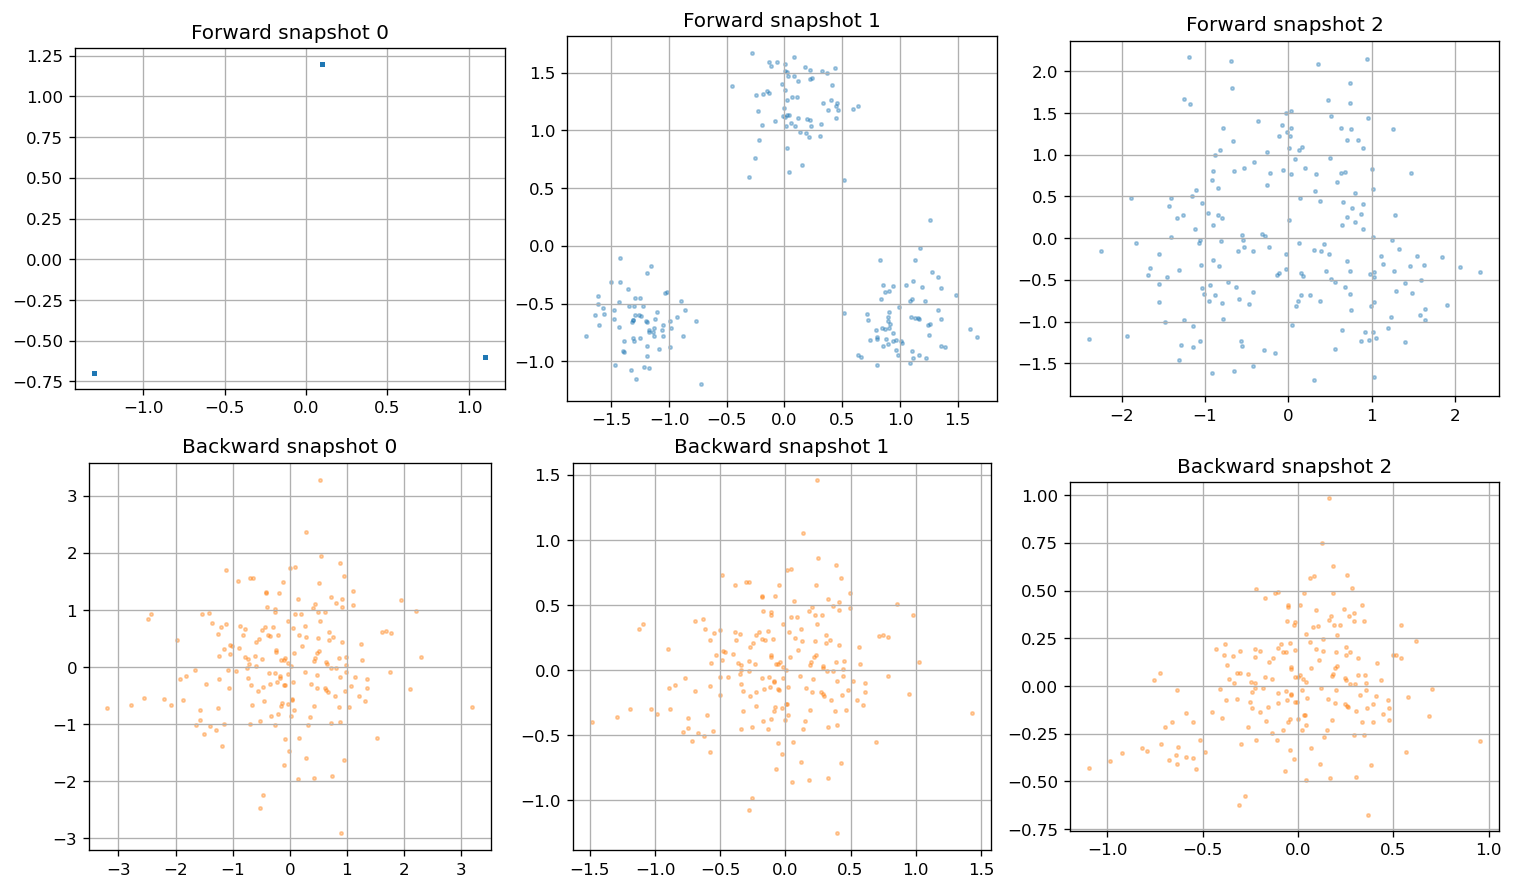

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.3), constrained_layout=True)
for i, snap in enumerate(fwd[:3]):
    ax = axes[0, i]
    ax.scatter(snap[:,0], snap[:,1], s=4, alpha=0.35)
    ax.set_title(f"Forward snapshot {i}")
    ax.set_aspect("equal")
for i, snap in enumerate(bwd[:3]):
    ax = axes[1, i]
    ax.scatter(snap[:,0], snap[:,1], s=4, alpha=0.35, color="tab:orange")
    ax.set_title(f"Backward snapshot {i}")
    ax.set_aspect("equal")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
